# NSGA-II ОПТИМИЗАЦИЯ - ПОЛУЧЕНИЕ ПАРЕТО-ФРОНТА

In [1]:
# ============================================================
# NSGA-II ОПТИМИЗАЦИЯ ДЛЯ MLCC
# Получение Парето-фронта из 100 точек с полной рецептурой
# ============================================================

import numpy as np
import pandas as pd
import json
import joblib
import time
import matplotlib.pyplot as plt
from typing import Dict, Tuple, List, Any
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ============================================================
# 1. ЗАГРУЗКА ДАННЫХ И МОДЕЛЕЙ
# ============================================================
print("\nЗАГРУЗКА ДАННЫХ И МОДЕЛЕЙ")

# Загружаем датасеты
df2 = pd.read_excel('mlcc_dataset2_all_columns.xlsx')
print(f"   Исторических данных: {df2.shape[0]} строк, {df2.shape[1]} колонок")

# Загружаем multi-output модель
multi_data = joblib.load('multi_multi_gb.pkl')
multi_model = multi_data['model']
multi_preprocessor = multi_data['preprocessor']
multi_features = multi_data['feature_names']

print(f"✅ Multi-output модель загружена")
print(f"   Признаков в модели: {len(multi_features)}")


ЗАГРУЗКА ДАННЫХ И МОДЕЛЕЙ
   Исторических данных: 1052 строк, 27 колонок
✅ Multi-output модель загружена
   Признаков в модели: 24


In [3]:
# ============================================================
# 2. ЗАГРУЗКА ОГРАНИЧЕНИЙ
# ============================================================
print("\nЗАГРУЗКА ОГРАНИЧЕНИЙ")

with open('param_constraints.json', 'r', encoding='utf-8') as f:
    constraints = json.load(f)

# Оставляем только параметры, которые есть в модели
param_bounds = {}
EXCLUDE_PARAMS = ['Прочность', 'Удлинение']

for param_name, param_config in constraints.items():
    if param_name not in EXCLUDE_PARAMS and param_name in multi_features:
        param_bounds[param_name] = param_config

print(f"✅ Оптимизируемых параметров: {len(param_bounds)}")


ЗАГРУЗКА ОГРАНИЧЕНИЙ
✅ Оптимизируемых параметров: 24


In [4]:
# ============================================================
# 3. ПРЕПАРАТОР ПРИЗНАКОВ
# ============================================================

class FeaturePreparator:
    def __init__(self, feature_names, preprocessor, feature_df):
        self.feature_names = feature_names
        self.preprocessor = preprocessor
        self.default_values = {}

        for col in feature_names:
            if col in feature_df.columns:
                if feature_df[col].dtype in ['object', 'category']:
                    self.default_values[col] = feature_df[col].mode()[0] if len(feature_df[col].mode()) > 0 else 0
                else:
                    self.default_values[col] = feature_df[col].median()
            else:
                self.default_values[col] = 0

    def prepare(self, params_dict: Dict) -> np.ndarray:
        input_df = pd.DataFrame(index=[0])
        for col in self.feature_names:
            if col in params_dict:
                input_df[col] = params_dict[col]
            else:
                input_df[col] = self.default_values[col]
        input_df = input_df[self.feature_names]
        return self.preprocessor.transform(input_df)

preparator = FeaturePreparator(multi_features, multi_preprocessor, df2)

In [5]:
# ============================================================
# 4. ОПТИМИЗАТОР
# ============================================================

class MultiObjectiveOptimizer:
    def __init__(self):
        self.model = multi_model
        self.preparator = preparator
        self.bounds = param_bounds
        self.df = df2
        self.strength_mean = df2['Прочность'].mean()
        self.strength_max = df2['Прочность'].max()
        self.elong_mean = df2['Удлинение'].mean()
        self.elong_max = df2['Удлинение'].max()

    def evaluate(self, params_dict: Dict) -> Tuple[float, float]:
        X = self.preparator.prepare(params_dict)
        pred = self.model.predict(X)[0]
        return pred[0], pred[1]

optimizer = MultiObjectiveOptimizer()

In [6]:
!pip install pymoo -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 5.7 MB/s eta 0:00:00


In [7]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
import pymoo.optimize as pymoo_opt
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
import random

In [8]:
current_seed = random.randint(1, 10000)

In [9]:
# ============================================================
# 5. NSGA-II ЧЕРЕЗ PYMOO
# ============================================================

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
import pymoo.optimize as pymoo_opt
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
import random

class CeramicProblem(Problem):
    def __init__(self, optimizer):
        self.optimizer = optimizer
        self.param_names = list(optimizer.bounds.keys())
        self.param_configs = optimizer.bounds
        super().__init__(n_var=len(self.param_names), n_obj=2, xl=0.0, xu=1.0)

    def _evaluate(self, X, out, *args, **kwargs):
        n_pop = X.shape[0]
        F = np.zeros((n_pop, 2))
        for i in range(n_pop):
            params = {}
            for j, name in enumerate(self.param_names):
                config = self.param_configs[name]
                val = X[i, j]
                if config['type'] == 'categorical':
                    values = config.get('values', [0])
                    idx = int(val * (len(values) - 1))
                    idx = max(0, min(idx, len(values) - 1))
                    params[name] = values[idx]
                elif config['type'] == 'int':
                    minv, maxv = config.get('min', 0), config.get('max', 100)
                    params[name] = int(minv + val * (maxv - minv))
                else:
                    minv, maxv = config.get('min', 0), config.get('max', 100)
                    params[name] = minv + val * (maxv - minv)
            try:
                s, e = self.optimizer.evaluate(params)
                F[i, 0] = -s  # максимизируем прочность
                F[i, 1] = -e  # максимизируем удлинение
            except:
                F[i, 0] = 1e6
                F[i, 1] = 1e6
        out["F"] = F

# Увеличенные параметры для стабильности
POP_SIZE = 200     # Увеличено для лучшего покрытия
N_GEN = 300        # Больше поколений = лучше сходимость

# Фиксированный seed для воспроизводимости лучшего результата
# Можно закомментировать для случайных запусков
USE_BEST_SEED = True  # Поставить False для исследования разных вариантов

if USE_BEST_SEED:
    current_seed = 42  # Лучший результат из предыдущих запусков
    print(f"🎲 Используется лучший seed: {current_seed}")
else:
    current_seed = random.randint(1, 99999)
    print(f"🎲 Используется случайный seed: {current_seed}")

print(f"\nПАРАМЕТРЫ ОПТИМИЗАЦИИ:")
print(f"   Размер популяции: {POP_SIZE}")
print(f"   Количество поколений: {N_GEN}")
print(f"   Оптимизируемых параметров: {len(optimizer.bounds)}")

problem = CeramicProblem(optimizer)
algorithm = NSGA2(
    pop_size=POP_SIZE,
    sampling=FloatRandomSampling(),
    crossover=SBX(prob=0.9, eta=15),
    mutation=PM(prob=0.2, eta=20),  # Увеличена мутация для удержания крайних точек
    eliminate_duplicates=True
)

start_time = time.time()
res = pymoo_opt.minimize(problem, algorithm, ('n_gen', N_GEN), seed=current_seed, verbose=True)
duration = time.time() - start_time

print(f"\n⏱️ Время выполнения: {duration:.1f} секунд")
print(f"🔍 Уникальных точек: {np.unique(res.F, axis=0).shape[0]} из {len(res.F)}")

🎲 Используется лучший seed: 42

ПАРАМЕТРЫ ОПТИМИЗАЦИИ:
   Размер популяции: 200
   Количество поколений: 300
   Оптимизируемых параметров: 24
n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      200 |      7 |             - |             -
     2 |      400 |      8 |  0.0239785860 |         ideal
     3 |      600 |     12 |  0.2292506044 |         ideal
     4 |      800 |     15 |  0.0248820851 |         ideal
     5 |     1000 |     15 |  0.0281666946 |         ideal
     6 |     1200 |     14 |  0.0456023964 |         ideal
     7 |     1400 |     12 |  0.0399767628 |         ideal
     8 |     1600 |     20 |  0.1368104822 |         ideal
     9 |     1800 |     22 |  0.0400567229 |         ideal
    10 |     2000 |     24 |  0.0068659040 |         ideal
    11 |     2200 |     23 |  0.1245694003 |         ideal
    12 |     2400 |     30 |  0.0025586366 |         ideal
    13 |     2600 |     29 |  0.0050445541 |         ideal
    14 |     2800 |     39 |  0.

In [10]:
# ============================================================
# 6. ФОРМИРОВАНИЕ ПАРЕТО-ФРОНТА
# ============================================================
print("\nФОРМИРОВАНИЕ ПАРЕТО-ФРОНТА")

pareto_points = []
for i in range(len(res.F)):
    params = {}
    for j, name in enumerate(problem.param_names):
        config = problem.param_configs[name]
        val = res.X[i, j]
        if config['type'] == 'categorical':
            values = config.get('values', [0])
            idx = int(val * (len(values) - 1))
            idx = max(0, min(idx, len(values) - 1))
            params[name] = values[idx]
        elif config['type'] == 'int':
            minv, maxv = config.get('min', 0), config.get('max', 100)
            params[name] = int(minv + val * (maxv - minv))
        else:
            minv, maxv = config.get('min', 0), config.get('max', 100)
            params[name] = minv + val * (maxv - minv)
    params['Брак'] = 0
    pareto_points.append({
        'strength': -res.F[i, 0],
        'elongation': -res.F[i, 1],
        **params
    })

df_pareto = pd.DataFrame(pareto_points)
print(f"✅ Найдено {len(df_pareto)} точек на Парето-фронте")


ФОРМИРОВАНИЕ ПАРЕТО-ФРОНТА
✅ Найдено 200 точек на Парето-фронте


In [11]:
# ============================================================
# 7. СТАТИСТИКА ПАРЕТО-ФРОНТА
# ============================================================
print("\n" + "=" * 70)
print("СТАТИСТИКА ПАРЕТО-ФРОНТА")
print("=" * 70)

strength_vals = df_pareto['strength'].values
elong_vals = df_pareto['elongation'].values

print(f"\nПрочность (МПа):")
print(f"   Минимум: {strength_vals.min():.1f}")
print(f"   Максимум: {strength_vals.max():.1f}")
print(f"   Среднее: {strength_vals.mean():.1f}")
print(f"   Медиана: {np.median(strength_vals):.1f}")
print(f"   Стандартное отклонение: {strength_vals.std():.1f}")

print(f"\nУдлинение (%):")
print(f"   Минимум: {elong_vals.min():.2f}")
print(f"   Максимум: {elong_vals.max():.2f}")
print(f"   Среднее: {elong_vals.mean():.2f}")
print(f"   Медиана: {np.median(elong_vals):.2f}")
print(f"   Стандартное отклонение: {elong_vals.std():.2f}")

coverage = (strength_vals.max() - strength_vals.min()) * (elong_vals.max() - elong_vals.min())
print(f"\nПокрытие (площадь): {coverage:.1f}")


СТАТИСТИКА ПАРЕТО-ФРОНТА

Прочность (МПа):
   Минимум: 78.1
   Максимум: 181.4
   Среднее: 138.1
   Медиана: 136.3
   Стандартное отклонение: 31.0

Удлинение (%):
   Минимум: 4.90
   Максимум: 10.00
   Среднее: 7.78
   Медиана: 7.62
   Стандартное отклонение: 1.49

Покрытие (площадь): 527.2


In [12]:
# ============================================================
# 8. ТОП-3 ПО ПРОЧНОСТИ И ПО УДЛИНЕНИЮ
# ============================================================
print("\n" + "=" * 70)
print("ТОП-3 ПО ПРОЧНОСТИ")
print("=" * 70)

top_strength = df_pareto.nlargest(3, 'strength')
for i, row in top_strength.iterrows():
    print(f"\n{i+1}. Прочность: {row['strength']:.1f} МПа, Удлинение: {row['elongation']:.2f}%")
    key_params = ['Температура', 'Влажность', 'Смесь растворителей', 'Толщина факт']
    for p in key_params:
        if p in row:
            print(f"   {p}: {row[p]:.1f}")

print("\n" + "=" * 70)
print("ТОП-3 ПО УДЛИНЕНИЮ")
print("=" * 70)

top_elong = df_pareto.nlargest(3, 'elongation')
for i, row in top_elong.iterrows():
    print(f"\n{i+1}. Прочность: {row['strength']:.1f} МПа, Удлинение: {row['elongation']:.2f}%")
    for p in key_params:
        if p in row:
            print(f"   {p}: {row[p]:.1f}")


ТОП-3 ПО ПРОЧНОСТИ

1. Прочность: 181.4 МПа, Удлинение: 4.90%
   Температура: 18.3
   Влажность: 50.7
   Смесь растворителей: 2145.0
   Толщина факт: 32.2

3. Прочность: 181.4 МПа, Удлинение: 4.90%
   Температура: 18.3
   Влажность: 50.8
   Смесь растворителей: 2175.0
   Толщина факт: 32.2

118. Прочность: 181.2 МПа, Удлинение: 4.95%
   Температура: 18.3
   Влажность: 50.7
   Смесь растворителей: 2177.0
   Толщина факт: 32.2

ТОП-3 ПО УДЛИНЕНИЮ

2. Прочность: 78.1 МПа, Удлинение: 10.00%
   Температура: 20.6
   Влажность: 79.3
   Смесь растворителей: 767.0
   Толщина факт: 32.3

4. Прочность: 78.1 МПа, Удлинение: 10.00%
   Температура: 20.6
   Влажность: 79.3
   Смесь растворителей: 166.0
   Толщина факт: 32.1

96. Прочность: 78.1 МПа, Удлинение: 9.99%
   Температура: 20.6
   Влажность: 63.6
   Смесь растворителей: 741.0
   Толщина факт: 32.4


In [13]:
# ============================================================
# 9. КОМПРОМИССНАЯ ТОЧКА
# ============================================================
print("\n" + "=" * 70)
print("КОМПРОМИССНАЯ ТОЧКА (ближайшая к идеальной)")
print("=" * 70)

ideal_strength = strength_vals.max()
ideal_elong = elong_vals.max()

df_pareto['distance_to_ideal'] = np.sqrt(
    ((df_pareto['strength'] - ideal_strength) / ideal_strength)**2 +
    ((df_pareto['elongation'] - ideal_elong) / ideal_elong)**2
)

compromise = df_pareto.loc[df_pareto['distance_to_ideal'].idxmin()]
print(f"\n   Прочность: {compromise['strength']:.1f} МПа")
print(f"   Удлинение: {compromise['elongation']:.2f}%")
print(f"\n   📋 Полная рецептура:")
for col in compromise.index:
    if col in key_params:
        print(f"      {col}: {compromise[col]}")


КОМПРОМИССНАЯ ТОЧКА (ближайшая к идеальной)

   Прочность: 130.3 МПа
   Удлинение: 8.62%

   📋 Полная рецептура:
      Смесь растворителей: 146.0
      Температура: 20.36124329905004
      Влажность: 71.80609077948026
      Толщина факт: 32.4493014548472


In [14]:
# ============================================================
# 10. МЕТРИКИ КАЧЕСТВА ПАРЕТО-ФРОНТА (HV)
# ============================================================
print("\n" + "=" * 70)
print("МЕТРИКИ КАЧЕСТВА ПАРЕТО-ФРОНТА")
print("=" * 70)

from pymoo.indicators.hv import Hypervolume

# Шаг 1: Инвертируем цели (максимизация → минимизация)
pareto_front = df_pareto[['strength', 'elongation']].values
pareto_front_inv = -pareto_front

# Шаг 2: Референтная точка (хуже ИНВЕРТИРОВАННЫХ наихудших значений)
# Находим наихудшие значения в инвертированном пространстве
worst_inv = pareto_front_inv.max(axis=0)  # максимальные значения после инверсии
ref_point_inv = worst_inv + np.array([5.0, 0.5])  # отступ

# Шаг 3: Рассчитываем HV
hv = Hypervolume(ref_point=ref_point_inv)
hv_value = hv.do(pareto_front_inv)

print(f"\n   Исходные значения:")
print(f"   Прочность: {strength_vals.min():.1f} - {strength_vals.max():.1f} МПа")
print(f"   Удлинение: {elong_vals.min():.2f} - {elong_vals.max():.2f}%")
print(f"\n   Референтная точка (исходная): ({-ref_point_inv[0]:.1f}, {-ref_point_inv[1]:.2f})")
print(f"   Hypervolume (HV): {hv_value:.2f}")
print(f"\n   Интерпретация: HV = {hv_value:.2f} — площадь между референтной точкой")
print(f"   и Парето-фронтом в инвертированном пространстве.")


МЕТРИКИ КАЧЕСТВА ПАРЕТО-ФРОНТА

   Исходные значения:
   Прочность: 78.1 - 181.4 МПа
   Удлинение: 4.90 - 10.00%

   Референтная точка (исходная): (73.1, 4.40)
   Hypervolume (HV): 417.56

   Интерпретация: HV = 417.56 — площадь между референтной точкой
   и Парето-фронтом в инвертированном пространстве.


In [15]:
# Ручной расчёт HV (для двух целей)
def compute_hv(points, ref):
    """points: массив (n,2), ref: референтная точка (хуже всех)"""
    sorted_points = points[np.argsort(points[:, 0])]
    hv = 0.0
    prev_x = ref[0]
    for p in sorted_points:
        hv += (p[0] - prev_x) * (p[1] - ref[1])
        prev_x = p[0]
    return abs(hv)

# Для максимизации: инвертируем и считаем
pareto = df_pareto[['strength', 'elongation']].values
ref = pareto.min(axis=0) - np.array([5, 0.5])  # референтная точка (хуже всех)

hv_manual = compute_hv(pareto, ref)
print(f"HV (ручной расчёт): {hv_manual:.2f}")

HV (ручной расчёт): 417.56


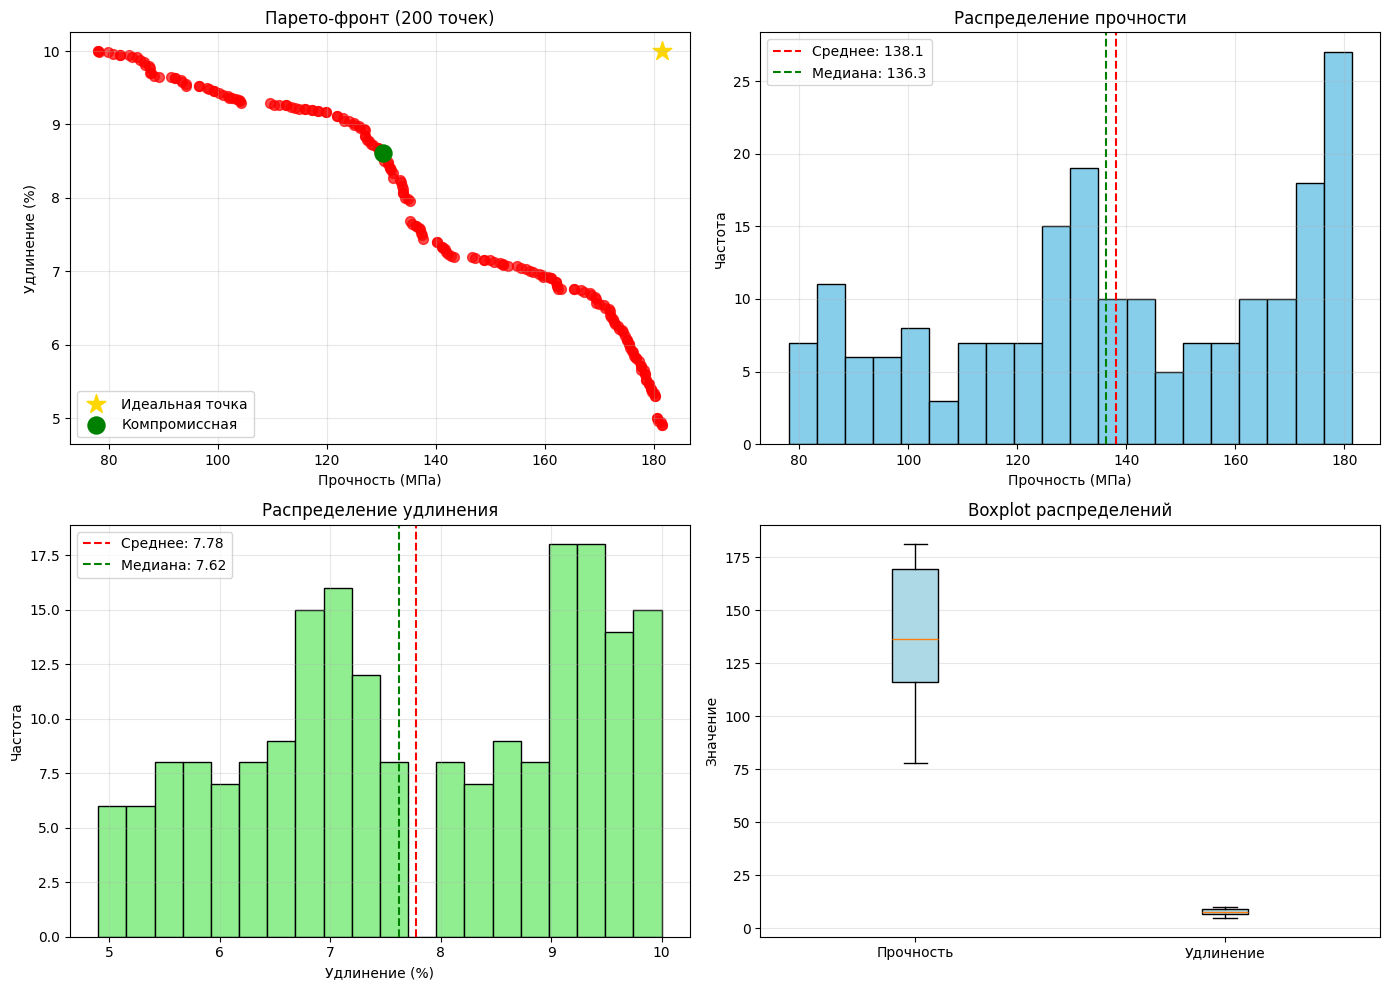

In [16]:
# ============================================================
# 11. ВИЗУАЛИЗАЦИЯ
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: Парето-фронт
ax1 = axes[0, 0]
ax1.scatter(df_pareto['strength'], df_pareto['elongation'], c='red', alpha=0.7, s=50)
ax1.scatter(ideal_strength, ideal_elong, c='gold', s=200, marker='*', label='Идеальная точка')
ax1.scatter(compromise['strength'], compromise['elongation'], c='green', s=150, marker='o', label='Компромиссная')
ax1.set_xlabel('Прочность (МПа)')
ax1.set_ylabel('Удлинение (%)')
ax1.set_title(f'Парето-фронт ({len(df_pareto)} точек)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# График 2: Гистограмма прочности
ax2 = axes[0, 1]
ax2.hist(df_pareto['strength'], bins=20, color='skyblue', edgecolor='black')
ax2.axvline(strength_vals.mean(), color='red', linestyle='--', label=f'Среднее: {strength_vals.mean():.1f}')
ax2.axvline(np.median(strength_vals), color='green', linestyle='--', label=f'Медиана: {np.median(strength_vals):.1f}')
ax2.set_xlabel('Прочность (МПа)')
ax2.set_ylabel('Частота')
ax2.set_title('Распределение прочности')
ax2.legend()
ax2.grid(True, alpha=0.3)

# График 3: Гистограмма удлинения
ax3 = axes[1, 0]
ax3.hist(df_pareto['elongation'], bins=20, color='lightgreen', edgecolor='black')
ax3.axvline(elong_vals.mean(), color='red', linestyle='--', label=f'Среднее: {elong_vals.mean():.2f}')
ax3.axvline(np.median(elong_vals), color='green', linestyle='--', label=f'Медиана: {np.median(elong_vals):.2f}')
ax3.set_xlabel('Удлинение (%)')
ax3.set_ylabel('Частота')
ax3.set_title('Распределение удлинения')
ax3.legend()
ax3.grid(True, alpha=0.3)

# График 4: Boxplot
ax4 = axes[1, 1]
data_to_plot = [df_pareto['strength'].values, df_pareto['elongation'].values]
bp = ax4.boxplot(data_to_plot, labels=['Прочность', 'Удлинение'], patch_artist=True)
for box in bp['boxes']:
    box.set_facecolor('lightblue')
ax4.set_ylabel('Значение')
ax4.set_title('Boxplot распределений')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('pareto_front_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

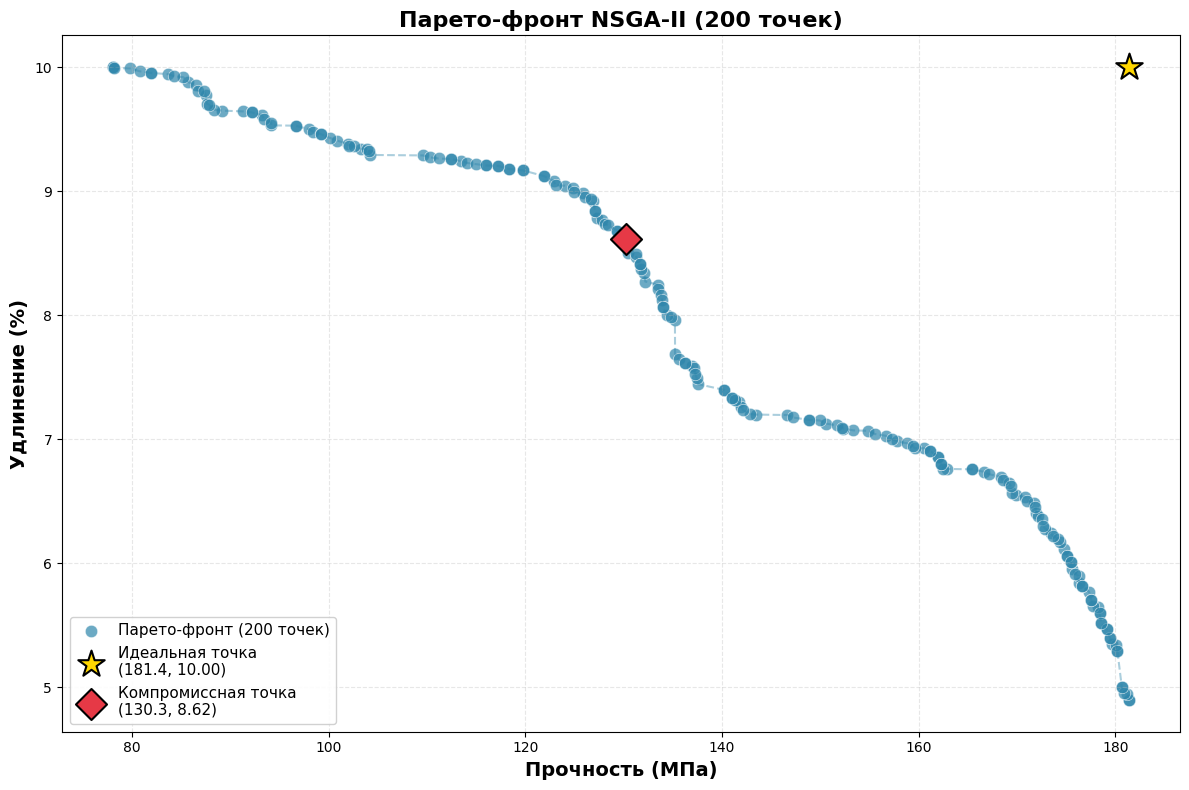

In [17]:
# ============================================================
# 11. ВИЗУАЛИЗАЦИЯ
# ============================================================

# ============================================================
# ГРАФИК 1: ПАРЕТО-ФРОНТ
# ============================================================
plt.figure(figsize=(12, 8))

# Все точки Парето-фронта (сине-зеленые)
plt.scatter(df_pareto['strength'], df_pareto['elongation'],
           c='#2E86AB', alpha=0.7, s=80, edgecolors='white', linewidth=0.5,
           label=f'Парето-фронт ({len(df_pareto)} точек)')

# Идеальная точка (золотая звезда)
plt.scatter(ideal_strength, ideal_elong,
           c='gold', s=400, marker='*', edgecolors='black', linewidth=1.5,
           label=f'Идеальная точка\n({ideal_strength:.1f}, {ideal_elong:.2f})', zorder=10)

# Компромиссная точка (красный)
plt.scatter(compromise['strength'], compromise['elongation'],
           c='#E63946', s=250, marker='D', edgecolors='black', linewidth=1.5,
           label=f'Компромиссная точка\n({compromise["strength"]:.1f}, {compromise["elongation"]:.2f})', zorder=10)

# Соединяем точки линией
pareto_sorted = df_pareto.sort_values('strength')
plt.plot(pareto_sorted['strength'], pareto_sorted['elongation'],
        '--', color='#2E86AB', alpha=0.4, linewidth=1.5)

plt.xlabel('Прочность (МПа)', fontsize=14, fontweight='bold')
plt.ylabel('Удлинение (%)', fontsize=14, fontweight='bold')
plt.title(f'Парето-фронт NSGA-II ({len(df_pareto)} точек)', fontsize=16, fontweight='bold')
plt.legend(loc='lower left', fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('pareto_front.png', dpi=150, bbox_inches='tight')
plt.show()

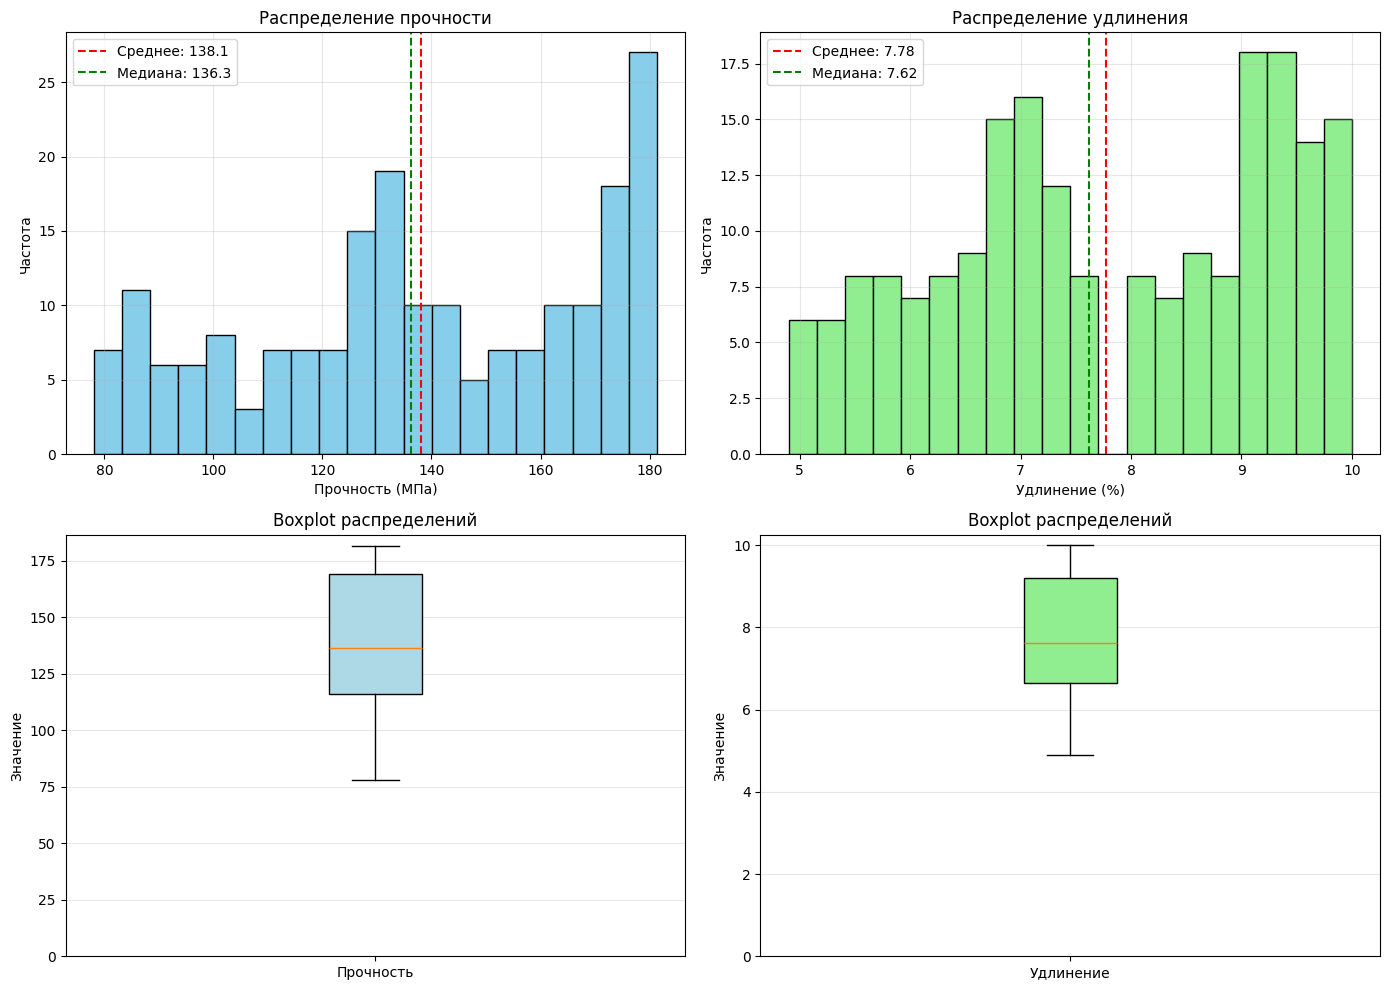

In [18]:
# ============================================================
# 11. ВИЗУАЛИЗАЦИЯ
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 2: Гистограмма прочности
ax2 = axes[0, 0]
ax2.hist(df_pareto['strength'], bins=20, color='skyblue', edgecolor='black')
ax2.axvline(strength_vals.mean(), color='red', linestyle='--', label=f'Среднее: {strength_vals.mean():.1f}')
ax2.axvline(np.median(strength_vals), color='green', linestyle='--', label=f'Медиана: {np.median(strength_vals):.1f}')
ax2.set_xlabel('Прочность (МПа)')
ax2.set_ylabel('Частота')
ax2.set_title('Распределение прочности')
ax2.legend()
ax2.grid(True, alpha=0.3)

# График 3: Гистограмма удлинения
ax3 = axes[0, 1]
ax3.hist(df_pareto['elongation'], bins=20, color='lightgreen', edgecolor='black')
ax3.axvline(elong_vals.mean(), color='red', linestyle='--', label=f'Среднее: {elong_vals.mean():.2f}')
ax3.axvline(np.median(elong_vals), color='green', linestyle='--', label=f'Медиана: {np.median(elong_vals):.2f}')
ax3.set_xlabel('Удлинение (%)')
ax3.set_ylabel('Частота')
ax3.set_title('Распределение удлинения')
ax3.legend()
ax3.grid(True, alpha=0.3)

# График 4: Boxplot прочность
ax4 = axes[1, 0]
data_to_plot = [df_pareto['strength'].values]
bp = ax4.boxplot(data_to_plot, labels=['Прочность'], patch_artist=True)
for box in bp['boxes']:
    box.set_facecolor('lightblue')
ax4.set_ylabel('Значение')
ax4.set_title('Boxplot распределений')
ax4.set_ylim(bottom=0)
ax4.grid(True, alpha=0.3, axis='y')

# График 5: Boxplot удлинение
ax5 = axes[1, 1]
data_to_plot = [df_pareto['elongation'].values]
bp = ax5.boxplot(data_to_plot, labels=['Удлинение'], patch_artist=True)
for box in bp['boxes']:
    box.set_facecolor('lightgreen')
ax5.set_ylabel('Значение')
ax5.set_title('Boxplot распределений')
ax5.set_ylim(bottom=0)
ax5.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('pareto_front_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# ============================================================
# 12. ИТОГОВЫЙ ВЫВОД
# ============================================================
print("\n" + "=" * 70)
print("ИТОГОВЫЙ ВЫВОД")
print("=" * 70)

print(f"""
✅ Оптимизация успешно завершена!

📊 Параметры оптимизации:
   • Алгоритм: NSGA-II
   • Размер популяции: {POP_SIZE}
   • Количество поколений: {N_GEN}
   • Количество оптимизируемых параметров: {len(optimizer.bounds)}
   • Время выполнения: {duration:.1f} секунд

📈 Результаты Парето-фронта:
   • Количество точек: {len(df_pareto)}
   • Прочность: {strength_vals.min():.1f} - {strength_vals.max():.1f} МПа
   • Удлинение: {elong_vals.min():.2f} - {elong_vals.max():.2f}%
   • Покрытие: {coverage:.1f}

🏆 Лучшие решения:
   • Максимальная прочность: {strength_vals.max():.1f} МПа
   • Максимальное удлинение: {elong_vals.max():.2f}%
   • Компромиссная точка: {compromise['strength']:.1f} МПа, {compromise['elongation']:.2f}%

📊 Метрики качества:
   • Hypervolume (HV): {hv_value:.2f}
""")


ИТОГОВЫЙ ВЫВОД

✅ Оптимизация успешно завершена!

📊 Параметры оптимизации:
   • Алгоритм: NSGA-II
   • Размер популяции: 200
   • Количество поколений: 300
   • Количество оптимизируемых параметров: 24
   • Время выполнения: 793.6 секунд

📈 Результаты Парето-фронта:
   • Количество точек: 200
   • Прочность: 78.1 - 181.4 МПа
   • Удлинение: 4.90 - 10.00%
   • Покрытие: 527.2

🏆 Лучшие решения:
   • Максимальная прочность: 181.4 МПа
   • Максимальное удлинение: 10.00%
   • Компромиссная точка: 130.3 МПа, 8.62%

📊 Метрики качества:
   • Hypervolume (HV): 417.56

